# 05. mrob vs Python Lie-Group Benchmarks

This notebook compares the project Python Lie helpers against raw `mrob` bindings for the SO(3)/SE(3) operations that `mrob` exposes. The raw `mrob` calls are executed in child processes so a broken geometry binding cannot terminate the notebook kernel.

The notebook also parses the local `mrob/src/pybind` files to show what is bound in source versus what is visible in the installed Python module.

In [1]:
from __future__ import annotations

from pathlib import Path
import json
import math
import os
import re
import subprocess
import sys
import tempfile
import textwrap
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd()
for candidate in (ROOT, *ROOT.parents):
    if (candidate / "src" / "calib_observability").exists():
        ROOT = candidate
        break
sys.path.insert(0, str(ROOT / "src"))

OUT = ROOT / "outputs" / "mrob_benchmarks"
OUT.mkdir(parents=True, exist_ok=True)

from calib_observability.lie_so3 import (
    so3_exp,
    so3_hat,
    so3_left_jacobian,
    so3_left_jacobian_inverse,
    so3_log,
)
from calib_observability.lie_se3 import (
    se3_adjoint,
    se3_exp,
    se3_hat,
    se3_inverse,
    se3_log,
    transform_point,
)


## Header Controls

In [2]:
# Benchmark size. Increase NUM_SAMPLES after confirming mrob is healthy.
NUM_SAMPLES = 5000
REPEATS = 5
RANDOM_SEED = 7

# Raw mrob calls are subprocess-protected. If the safety probe fails, the
# notebook skips raw timing by default and records why.
RUN_MROB_BENCHMARKS_EVEN_IF_PROBE_FAILS = False
SUBPROCESS_TIMEOUT_SECONDS = 30.0

# Local mrob source files used only for binding introspection.
MROB_SOURCE_ROOT = Path("/home/camel/Skoltech/Mobile_Robotics_Lab/mrob")
MROB_SE3_PYBIND = MROB_SOURCE_ROOT / "src" / "pybind" / "SE3py.cpp"
MROB_FGRAPH_PYBIND = MROB_SOURCE_ROOT / "src" / "pybind" / "FGraphPy.cpp"

BENCHMARK_CASES = [
    "so3_hat",
    "so3_exp",
    "so3_log",
    "so3_left_jacobian",
    "so3_left_jacobian_inverse",
    "se3_hat",
    "se3_exp",
    "se3_log",
    "se3_inverse",
    "se3_adjoint",
    "transform_point",
]

print({
    "num_samples": NUM_SAMPLES,
    "repeats": REPEATS,
    "python": sys.executable,
    "output_dir": str(OUT),
})


{'num_samples': 5000, 'repeats': 5, 'python': '/home/camel/anaconda3/bin/python', 'output_dir': '/home/camel/Skoltech/phd_proposal/outputs/mrob_benchmarks'}


## Parse mrob Bindings

This cell reads the local pybind files and compares source-bound names against the installed `mrob` module. It is useful because the source tree may expose functions that the currently installed wheel/build does not.

In [3]:
def extract_pybind_names(path: Path) -> list[str]:
    if not path.exists():
        return []
    text = path.read_text(encoding="utf-8", errors="replace")
    names = set(re.findall(r'\.def\(\s*"([^"]+)"', text))
    names.update(re.findall(r'm\.def\(\s*"([^"]+)"', text))
    class_names = re.findall(r'py::class_<[^>]+>\(m,\s*"([^"]+)"', text)
    names.update(class_names)
    return sorted(names)

source_bindings = {
    "SE3py.cpp": extract_pybind_names(MROB_SE3_PYBIND),
    "FGraphPy.cpp": extract_pybind_names(MROB_FGRAPH_PYBIND),
}
try:
    import mrob
    installed_mrob_symbols = sorted(name for name in dir(mrob) if not name.startswith("_"))
    mrob_import_error = None
except Exception as exc:
    mrob = None
    installed_mrob_symbols = []
    mrob_import_error = repr(exc)

source_geometry_names = set(source_bindings["SE3py.cpp"])
installed_geometry_names = source_geometry_names.intersection(installed_mrob_symbols)
missing_from_installed = sorted(source_geometry_names - set(installed_mrob_symbols))

print("mrob import error:", mrob_import_error)
print("geometry names in source:", source_bindings["SE3py.cpp"])
print("geometry names visible in installed mrob:", sorted(installed_geometry_names))
print("geometry names present in source but not visible in installed mrob:", missing_from_installed)

binding_rows = []
for file_name, names in source_bindings.items():
    for name in names:
        binding_rows.append({
            "source_file": file_name,
            "binding_name": name,
            "visible_in_installed_mrob": name in installed_mrob_symbols,
        })
bindings_df = pd.DataFrame(binding_rows)
display(bindings_df)
bindings_df.to_csv(OUT / "mrob_pybind_bindings.csv", index=False)


mrob import error: None
geometry names in source: ['Ln', 'Ln_from_position_to_omega_acc', 'R', 'SE3Cov', 'SE3tc', 'SE3vel', 'SO3', 'T', 'T_SE3', 'T_compact', '__mul__', '__repr__', '__str__', 'adj', 'compound_2nd_order', 'compound_4th_order', 'cov', 'curley_wedge', 'distance', 'distance_rotation', 'distance_trans', 'hat3', 'hat6', 'inv', 'inv_left_jacobian_SO3', 'inv_left_jacobian_tc', 'isSE3', 'isSO3', 'left_jacobian_SO3', 'mul', 'p', 'print', 'quat_to_so3', 'rpy_to_so3', 'set_time', 'so3_to_quat', 't', 'tc', 'time', 'transform', 'transform_array', 'update', 'update_lhs', 'update_rhs', 'v', 'vel']
geometry names visible in installed mrob: ['SE3Cov', 'SE3tc', 'SE3vel', 'SO3', 'curley_wedge', 'hat3', 'hat6', 'inv_left_jacobian_SO3', 'inv_left_jacobian_tc', 'isSE3', 'isSO3', 'left_jacobian_SO3', 'quat_to_so3', 'rpy_to_so3', 'so3_to_quat']
geometry names present in source but not visible in installed mrob: ['Ln', 'Ln_from_position_to_omega_acc', 'R', 'T', 'T_SE3', 'T_compact', '__mul__', 

,source_file,binding_name,visible_in_installed_mrob
0,SE3py.cpp,Ln,False
1,SE3py.cpp,Ln_from_position_to_omega_acc,False
2,SE3py.cpp,R,False
3,SE3py.cpp,SE3Cov,True
4,SE3py.cpp,SE3tc,True
...,...,...,...
90,FGraphPy.cpp,get_vector_b,False
91,FGraphPy.cpp,number_factors,False
92,FGraphPy.cpp,number_nodes,False
93,FGraphPy.cpp,print,False


## Data and Project/Python Timing Helpers

The project implementation is the Python Lie helper layer used by this repository. On machines where raw `mrob` is safe, the project layer may delegate some calls to `mrob`; on this machine it falls back to the Python formulas because the installed `mrob` geometry constructors terminate Python.

In [4]:
rng = np.random.default_rng(RANDOM_SEED)
so3_tangents = rng.normal(scale=0.3, size=(NUM_SAMPLES, 3))
se3_tangents = np.hstack([
    rng.normal(scale=0.3, size=(NUM_SAMPLES, 3)),
    rng.normal(scale=1.0, size=(NUM_SAMPLES, 3)),
])
points = rng.normal(size=(NUM_SAMPLES, 3))
so3_rotations = np.stack([so3_exp(omega) for omega in so3_tangents], axis=0)
se3_transforms = np.stack([se3_exp(xi) for xi in se3_tangents], axis=0)


def median_time_seconds(function, repeats: int = REPEATS) -> float:
    timings = []
    for _ in range(repeats):
        start = time.perf_counter()
        function()
        timings.append(time.perf_counter() - start)
    return float(np.median(timings))


def benchmark_project_case(case_name: str) -> dict[str, object]:
    def run_case():
        if case_name == "so3_hat":
            for omega in so3_tangents:
                so3_hat(omega)
        elif case_name == "so3_exp":
            for omega in so3_tangents:
                so3_exp(omega)
        elif case_name == "so3_log":
            for rotation in so3_rotations:
                so3_log(rotation)
        elif case_name == "so3_left_jacobian":
            for omega in so3_tangents:
                so3_left_jacobian(omega)
        elif case_name == "so3_left_jacobian_inverse":
            for omega in so3_tangents:
                so3_left_jacobian_inverse(omega)
        elif case_name == "se3_hat":
            for xi in se3_tangents:
                se3_hat(xi)
        elif case_name == "se3_exp":
            for xi in se3_tangents:
                se3_exp(xi)
        elif case_name == "se3_log":
            for transform in se3_transforms:
                se3_log(transform)
        elif case_name == "se3_inverse":
            for transform in se3_transforms:
                se3_inverse(transform)
        elif case_name == "se3_adjoint":
            for transform in se3_transforms:
                se3_adjoint(transform)
        elif case_name == "transform_point":
            for transform, point in zip(se3_transforms, points):
                transform_point(transform, point)
        else:
            raise ValueError(f"unknown case: {case_name}")

    elapsed = median_time_seconds(run_case)
    return {
        "backend": "project_python_layer",
        "case": case_name,
        "status": "ok",
        "seconds_total": elapsed,
        "microseconds_per_call": 1e6 * elapsed / NUM_SAMPLES,
        "notes": "project Lie helper layer",
    }


## Raw mrob Subprocess Timing Helpers

The raw benchmark code runs in a separate Python process. If `mrob` crashes, the row is marked as failed and the notebook continues.

In [5]:
MROB_SUBPROCESS_CODE = r"""
from __future__ import annotations
import json
import sys
import time

import numpy as np

case_name = sys.argv[1]
num_samples = int(sys.argv[2])
repeats = int(sys.argv[3])
random_seed = int(sys.argv[4])

rng = np.random.default_rng(random_seed)
so3_tangents = rng.normal(scale=0.3, size=(num_samples, 3)).astype(np.float64)
se3_tangents = np.hstack([
    rng.normal(scale=0.3, size=(num_samples, 3)),
    rng.normal(scale=1.0, size=(num_samples, 3)),
]).astype(np.float64)
points = rng.normal(size=(num_samples, 3)).astype(np.float64)

import mrob

# Build reference arrays inside the raw mrob process so timing inputs match the
# raw backend's conventions and do not depend on project helpers.
so3_rotations = []
se3_transforms = []
for omega, xi in zip(so3_tangents, se3_tangents):
    so3_rotations.append(mrob.SO3(omega).R())
    se3_transforms.append(mrob.SE3(xi).T())
so3_rotations = np.asarray(so3_rotations)
se3_transforms = np.asarray(se3_transforms)


def run_case():
    if case_name == "so3_hat":
        for omega in so3_tangents:
            mrob.hat3(omega)
    elif case_name == "so3_exp":
        for omega in so3_tangents:
            mrob.SO3(omega).R()
    elif case_name == "so3_log":
        for rotation in so3_rotations:
            mrob.SO3(rotation).Ln()
    elif case_name == "so3_left_jacobian":
        if not hasattr(mrob, "left_jacobian_SO3"):
            raise AttributeError("installed mrob does not expose left_jacobian_SO3")
        for omega in so3_tangents:
            mrob.left_jacobian_SO3(omega)
    elif case_name == "so3_left_jacobian_inverse":
        if not hasattr(mrob, "inv_left_jacobian_SO3"):
            raise AttributeError("installed mrob does not expose inv_left_jacobian_SO3")
        for omega in so3_tangents:
            mrob.inv_left_jacobian_SO3(omega)
    elif case_name == "se3_hat":
        for xi in se3_tangents:
            mrob.hat6(xi)
    elif case_name == "se3_exp":
        for xi in se3_tangents:
            mrob.SE3(xi).T()
    elif case_name == "se3_log":
        for transform in se3_transforms:
            mrob.SE3(transform).Ln()
    elif case_name == "se3_inverse":
        for transform in se3_transforms:
            mrob.SE3(transform).inv().T()
    elif case_name == "se3_adjoint":
        for transform in se3_transforms:
            mrob.SE3(transform).adj()
    elif case_name == "transform_point":
        for transform, point in zip(se3_transforms, points):
            mrob.SE3(transform).transform(point)
    else:
        raise ValueError(f"unknown case: {case_name}")

# Warmup keeps constructor/import artifacts out of the measured loop.
run_case()
timings = []
for _ in range(repeats):
    start = time.perf_counter()
    run_case()
    timings.append(time.perf_counter() - start)

elapsed = float(np.median(timings))
print(json.dumps({
    "backend": "raw_mrob",
    "case": case_name,
    "status": "ok",
    "seconds_total": elapsed,
    "microseconds_per_call": 1e6 * elapsed / num_samples,
    "notes": "raw mrob pybind calls in subprocess",
}))
"""


def run_subprocess_python(code_text: str, args: list[str] | None = None, timeout: float = SUBPROCESS_TIMEOUT_SECONDS):
    with tempfile.NamedTemporaryFile("w", suffix=".py", delete=False, encoding="utf-8") as script_file:
        script_file.write(code_text)
        script_path = script_file.name
    try:
        completed = subprocess.run(
            [sys.executable, script_path, *(args or [])],
            text=True,
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
            timeout=timeout,
            check=False,
        )
    finally:
        Path(script_path).unlink(missing_ok=True)
    return completed


def probe_mrob_geometry() -> dict[str, object]:
    probe_code = """
import json
import numpy as np
import mrob
omega = np.array([0.01, -0.02, 0.03], dtype=np.float64)
xi = np.array([0.01, -0.02, 0.03, 0.1, -0.2, 0.3], dtype=np.float64)
out = {
    "hat3_shape": list(np.asarray(mrob.hat3(omega)).shape),
    "hat6_shape": list(np.asarray(mrob.hat6(xi)).shape),
    "so3_R_shape": list(np.asarray(mrob.SO3(omega).R()).shape),
    "so3_Ln_shape": list(np.asarray(mrob.SO3(np.eye(3)).Ln()).shape),
    "se3_T_shape": list(np.asarray(mrob.SE3(xi).T()).shape),
    "se3_Ln_shape": list(np.asarray(mrob.SE3(np.eye(4)).Ln()).shape),
}
print(json.dumps(out))
"""
    completed = run_subprocess_python(probe_code, timeout=SUBPROCESS_TIMEOUT_SECONDS)
    if completed.returncode != 0:
        return {
            "status": "failed",
            "returncode": completed.returncode,
            "stdout": completed.stdout.strip(),
            "stderr": completed.stderr.strip()[-1000:],
        }
    try:
        payload = json.loads(completed.stdout.strip().splitlines()[-1])
    except Exception as exc:
        return {
            "status": "failed_to_parse",
            "returncode": completed.returncode,
            "stdout": completed.stdout.strip(),
            "stderr": completed.stderr.strip()[-1000:],
            "error": repr(exc),
        }
    payload["status"] = "ok"
    return payload


def benchmark_raw_mrob_case(case_name: str) -> dict[str, object]:
    completed = run_subprocess_python(
        MROB_SUBPROCESS_CODE,
        args=[case_name, str(NUM_SAMPLES), str(REPEATS), str(RANDOM_SEED)],
        timeout=SUBPROCESS_TIMEOUT_SECONDS,
    )
    if completed.returncode != 0:
        return {
            "backend": "raw_mrob",
            "case": case_name,
            "status": "process_failed",
            "seconds_total": np.nan,
            "microseconds_per_call": np.nan,
            "notes": f"returncode={completed.returncode}; stderr={completed.stderr.strip()[-500:]}",
        }
    try:
        return json.loads(completed.stdout.strip().splitlines()[-1])
    except Exception as exc:
        return {
            "backend": "raw_mrob",
            "case": case_name,
            "status": "parse_failed",
            "seconds_total": np.nan,
            "microseconds_per_call": np.nan,
            "notes": f"{exc!r}; stdout={completed.stdout.strip()[-500:]}",
        }


## Run Benchmarks

In [6]:
mrob_probe = probe_mrob_geometry()
print("mrob geometry probe:")
print(json.dumps(mrob_probe, indent=2))

benchmark_rows = []
for case_name in BENCHMARK_CASES:
    benchmark_rows.append(benchmark_project_case(case_name))

raw_mrob_enabled = mrob_probe.get("status") == "ok" or RUN_MROB_BENCHMARKS_EVEN_IF_PROBE_FAILS
if raw_mrob_enabled:
    for case_name in BENCHMARK_CASES:
        benchmark_rows.append(benchmark_raw_mrob_case(case_name))
else:
    reason = f"skipped because mrob probe status is {mrob_probe.get('status')!r}"
    for case_name in BENCHMARK_CASES:
        benchmark_rows.append({
            "backend": "raw_mrob",
            "case": case_name,
            "status": "skipped",
            "seconds_total": np.nan,
            "microseconds_per_call": np.nan,
            "notes": reason,
        })

benchmarks_df = pd.DataFrame(benchmark_rows)
benchmarks_df.to_csv(OUT / "mrob_vs_project_lie_benchmarks.csv", index=False)
display(benchmarks_df)


mrob geometry probe:
{
  "hat3_shape": [
    3,
    3
  ],
  "hat6_shape": [
    4,
    4
  ],
  "so3_R_shape": [
    3,
    3
  ],
  "so3_Ln_shape": [
    3
  ],
  "se3_T_shape": [
    4,
    4
  ],
  "se3_Ln_shape": [
    6
  ],
  "status": "ok"
}


,backend,case,status,seconds_total,microseconds_per_call,notes
0,project_python_layer,so3_hat,ok,0.035544,7.108754,project Lie helper layer
1,project_python_layer,so3_exp,ok,0.054498,10.899607,project Lie helper layer
2,project_python_layer,so3_log,ok,0.176552,35.310387,project Lie helper layer
3,project_python_layer,so3_left_jacobian,ok,0.167020,33.404093,project Lie helper layer
4,project_python_layer,so3_left_jacobian_inverse,ok,0.165394,33.078818,project Lie helper layer
5,project_python_layer,se3_hat,ok,0.036317,7.263447,project Lie helper layer
6,project_python_layer,se3_exp,ok,0.050977,10.195417,project Lie helper layer
7,project_python_layer,se3_log,ok,0.045564,9.112787,project Lie helper layer
8,project_python_layer,se3_inverse,ok,0.057456,11.491161,project Lie helper layer
9,project_python_layer,se3_adjoint,ok,0.058510,11.702050,project Lie helper layer


## Speedup Table

In [7]:
project_times = benchmarks_df.query("backend == 'project_python_layer' and status == 'ok'").set_index("case")["microseconds_per_call"]
mrob_times = benchmarks_df.query("backend == 'raw_mrob' and status == 'ok'").set_index("case")["microseconds_per_call"]
summary_rows = []
for case_name in BENCHMARK_CASES:
    project_us = float(project_times.get(case_name, np.nan))
    mrob_us = float(mrob_times.get(case_name, np.nan))
    summary_rows.append({
        "case": case_name,
        "project_us_per_call": project_us,
        "raw_mrob_us_per_call": mrob_us,
        "speedup_project_over_mrob": project_us / mrob_us if np.isfinite(project_us) and np.isfinite(mrob_us) and mrob_us > 0 else np.nan,
    })
summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(OUT / "mrob_vs_project_lie_summary.csv", index=False)
display(summary_df)


,case,project_us_per_call,raw_mrob_us_per_call,speedup_project_over_mrob
0,so3_hat,7.108754,1.423382,4.994270
1,so3_exp,10.899607,3.717318,2.932116
2,so3_log,35.310387,3.269430,10.800165
3,so3_left_jacobian,33.404093,2.041513,16.362420
4,so3_left_jacobian_inverse,33.078818,1.677165,19.723051
5,se3_hat,7.263447,1.781241,4.077744
6,se3_exp,10.195417,3.821757,2.667730
7,se3_log,9.112787,3.584465,2.542300
8,se3_inverse,11.491161,4.195939,2.738639
9,se3_adjoint,11.702050,3.232584,3.620030


## Plot Timings

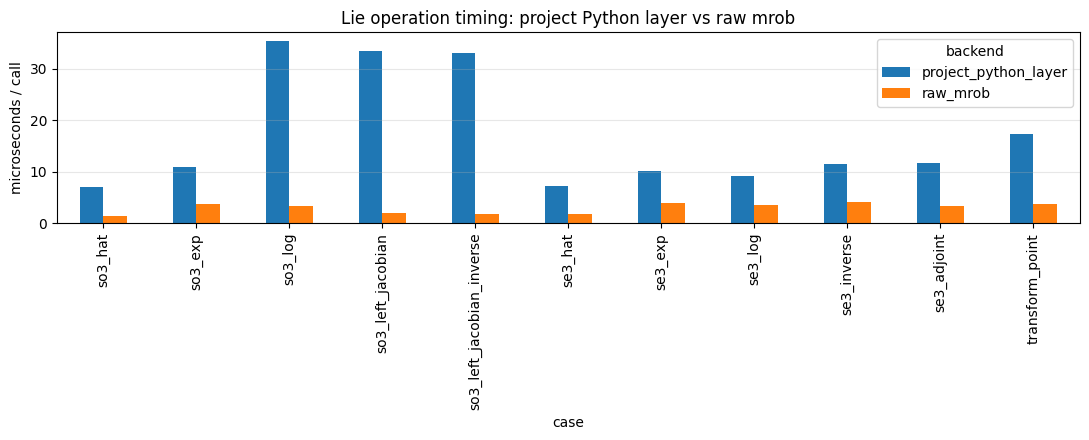

/home/camel/Skoltech/phd_proposal/outputs/mrob_benchmarks/mrob_vs_project_lie_timing.png


In [8]:
plot_df = benchmarks_df[np.isfinite(benchmarks_df["microseconds_per_call"])].copy()
if plot_df.empty:
    print("No finite timings to plot.")
else:
    fig, ax = plt.subplots(figsize=(11, 4.5))
    pivot = plot_df.pivot(index="case", columns="backend", values="microseconds_per_call").reindex(BENCHMARK_CASES)
    pivot.plot(kind="bar", ax=ax)
    ax.set_ylabel("microseconds / call")
    ax.set_title("Lie operation timing: project Python layer vs raw mrob")
    ax.grid(True, axis="y", alpha=0.3)
    fig.tight_layout()
    figure_path = OUT / "mrob_vs_project_lie_timing.png"
    fig.savefig(figure_path, dpi=160)
    plt.show()
    print(figure_path)


## Notes on Interpreting Results

- `project_python_layer` is the implementation currently imported from `src/calib_observability/lie_*.py`.
- `raw_mrob` is intentionally isolated in a subprocess. A `process_failed` or `skipped` row means the binding was unavailable or unsafe in this Python environment, not that the mathematical operation is absent from mrob source.
- `SE2` is not benchmarked against raw `mrob` because the inspected Python bindings do not expose native `SE2`/`SO2` classes.
- The source file shows `left_jacobian_SO3` and `inv_left_jacobian_SO3`, but the installed module used here may not expose them. The binding table above makes that mismatch explicit.